# Which severe reports came with rotation and lightning?

Turn one Storm Events tornado report into a labeled feature row by joining it to
the nearest NEXRAD Level II volume, the nearest MRMS mid-level rotation track,
and the GLM flashes around it, then repeat the radar-grid and lightning features
over twelve tornado, hail, and thunderstorm-wind reports from the same Oklahoma
evening. The result is a small labeled table of inputs for a classifier that this
notebook deliberately does not train. This worked case uses event **1184052**,
KTLX, MRMS `RotationTrackML30min_00.50`, and GOES-16 GLM.

Requires **usdata v0.15.0 or later** and the repository's examples, radar, netcdf,
and grib environments (`just notebooks`). The 80 locked source files total about
68 MB; an empty-cache restoration downloads them once more. Each MRMS grid decodes
to about 1.2 GB before it is cropped. Run every cell in order. Saved outputs are
a dated snapshot; retain the manifest, lockfile, and raw bytes for your own analysis.

In [1]:
import gc
import sys
import tempfile
import time
from datetime import UTC, datetime, timedelta, timezone
from importlib.metadata import version
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyproj import Geod

from usdata import build_query, get, select_by_time
from usdata.providers import load_adapter
from usdata.pull import pull, verify

manifest = Path("examples/tornado-classification/dataset.yaml")
if not manifest.is_file():
    manifest = Path("dataset.yaml")
notebook_started = time.perf_counter()
print("Executed UTC:", datetime.now(UTC).isoformat(timespec="seconds"))
print("Python:", sys.version.split()[0])
print(
    {name: version(name) for name in ("usdata", "pandas", "xarray", "xradar", "eccodes", "pyproj")}
)

Executed UTC: 2026-09-14T18:27:22+00:00
Python: 3.14.7
{'usdata': '0.14.0', 'pandas': '3.0.5', 'xarray': '2026.7.0', 'xradar': '0.12.0', 'eccodes': '2.48.0', 'pyproj': '3.8.0'}


## Pin and verify source bytes

The manifest records four inputs: the 2024 Storm Events archive, one KTLX volume
at its discovered scan start, nine two-minute MRMS rotation grids, and sixty-nine
20-second GLM files (80 files in all). Each dataset returns whole files; every spatial and temporal
narrowing below happens locally after download. NCEI can revise the annual
archive; the lock pins its creation-date filename and checksum. On later runs,
`pull` restores the lock without repeating provider discovery.

In [2]:
started = time.perf_counter()
result = pull(manifest)
assert verify(manifest) == []
by_dataset: dict[str, list] = {}
for item in result.fetched:
    by_dataset.setdefault(item.asset.dataset_id, []).append(item)
print("Pull seconds:", round(time.perf_counter() - started, 2))
print("Total source bytes:", sum(item.provenance.size for item in result.fetched))
summary = pd.DataFrame(
    {
        "dataset": dataset,
        "files": len(items),
        "bytes": sum(item.provenance.size for item in items),
        "first": min(item.asset.id for item in items),
        "retrieved_utc": max(item.provenance.retrieved_at for item in items).isoformat(
            timespec="seconds"
        ),
    }
    for dataset, items in by_dataset.items()
)
assert set(summary.dataset) == {
    "noaa:storm-events",
    "noaa:nexrad-level2",
    "noaa:mrms",
    "noaa:goes-glm",
}
summary

Pull seconds: 14.93
Total source bytes: 67817291


,dataset,files,bytes,first,retrieved_utc
0,noaa:storm-events,1,12693243,StormEvents_details-ftp_v1.0_d2024_c20260728.c...,2026-09-14T18:27:25+00:00
1,noaa:nexrad-level2,1,19826021,KTLX20240507_044053_V06,2026-09-14T18:27:28+00:00
2,noaa:mrms,9,1678478,MRMS_RotationTrackML30min_00.50_20240507-04280...,2026-09-14T18:27:29+00:00
3,noaa:goes-glm,69,33619549,OR_GLM-L2-LCFA_G16_s20241280425000_e2024128042...,2026-09-14T18:27:37+00:00


## Read the reports' time convention explicitly

[NCEI event 1184052](https://www.ncei.noaa.gov/stormevents/eventdetails.jsp?id=1184052)
is an EF1 tornado report beginning in Oklahoma County at 22:39 on May 6, 2024.
The [bulk-format reference](https://www.ncei.noaa.gov/pub/data/swdi/stormevents/csvfiles/Storm-Data-Bulk-csv-Format.pdf)
identifies local standard time and the `CZ_TIMEZONE` offset. Every Oklahoma row
in this archive says `CST-6`: use **fixed UTC−6**, giving 04:39 UTC on May 7. A
regional zone with daylight saving would shift the case by an hour, so the cell
below refuses any other label rather than guessing. Coordinates mark the reported
path start; a report record is not necessarily an independent storm.

The twelve-report table takes the first twelve Oklahoma tornado, hail, and
thunderstorm-wind rows beginning between 04:30 and 04:42 UTC, ordered by begin
time and event id. That fourteen-minute span is the evening's most active stretch
around the case and keeps every needed MRMS and GLM file inside one manifest.

In [3]:
columns = [
    "EVENT_ID",
    "EVENT_TYPE",
    "STATE",
    "CZ_NAME",
    "BEGIN_DATE_TIME",
    "CZ_TIMEZONE",
    "BEGIN_LAT",
    "BEGIN_LON",
    "TOR_F_SCALE",
    "MAGNITUDE",
]
frame = by_dataset["noaa:storm-events"][0].open(usecols=columns)
reports = frame.loc[
    frame.STATE.eq("OKLAHOMA") & frame.EVENT_TYPE.isin(["Tornado", "Hail", "Thunderstorm Wind"])
].copy()
if set(reports.CZ_TIMEZONE) != {"CST-6"}:
    raise ValueError(f"Review source timezones before matching: {set(reports.CZ_TIMEZONE)}")
local = pd.to_datetime(reports.BEGIN_DATE_TIME, format="%d-%b-%y %H:%M:%S")
reports["begin_utc"] = local.dt.tz_localize(timezone(timedelta(hours=-6))).dt.tz_convert("UTC")
reports["BEGIN_LAT"] = reports.BEGIN_LAT.astype(float)
reports["BEGIN_LON"] = reports.BEGIN_LON.astype(float)
assert reports[["BEGIN_LAT", "BEGIN_LON"]].notna().all().all()

case = reports.loc[reports.EVENT_ID.eq("1184052")].iloc[0]
event_time = case.begin_utc.to_pydatetime()
lat, lon = float(case.BEGIN_LAT), float(case.BEGIN_LON)
print(
    "Case:", case[["EVENT_ID", "EVENT_TYPE", "CZ_NAME", "BEGIN_DATE_TIME", "TOR_F_SCALE"]].to_dict()
)
print("Case start UTC:", event_time.isoformat())

window = reports.loc[
    reports.begin_utc.between("2024-05-07T04:30:00Z", "2024-05-07T04:42:00Z")
].sort_values(["begin_utc", "EVENT_ID"])
selected = window.head(12).reset_index(drop=True)
assert set(selected.EVENT_TYPE) == {"Tornado", "Hail", "Thunderstorm Wind"}
assert case.EVENT_ID in set(selected.EVENT_ID)
print("Reports in the 04:30-04:42 UTC window:", len(window), "· selected:", len(selected))
print(selected.EVENT_TYPE.value_counts().to_dict())
del frame
gc.collect();

Case: {'EVENT_ID': '1184052', 'EVENT_TYPE': 'Tornado', 'CZ_NAME': 'OKLAHOMA', 'BEGIN_DATE_TIME': '06-MAY-24 22:39:00', 'TOR_F_SCALE': 'EF1'}
Case start UTC: 2024-05-07T04:39:00+00:00
Reports in the 04:30-04:42 UTC window: 15 · selected: 12
{'Thunderstorm Wind': 9, 'Hail': 2, 'Tornado': 1}


## Check the locked selections against live listings

The manifest's radar and MRMS bounds equal scan starts found during discovery.
Rank each provider's live candidates within ±5 minutes of the case time by
absolute start difference with `select_by_time` and require the winner to be
the locked asset. For GLM, whose 20-second files are all used rather than one
being chosen, require every listed file starting within ±5 minutes of the case
to be in the lock. If any check fails, investigate changed source listings or
report revisions before editing the manifest and deliberately resolving a new
lock. The tolerance is an analysis choice, not an SDK default. This cell is
deliberately live; it is not needed merely to restore an existing analysis.

In [4]:
tolerance = timedelta(minutes=5)
locked = {dataset: {item.asset.id for item in items} for dataset, items in by_dataset.items()}
checks = []
for dataset_id, params in [
    ("noaa:nexrad-level2", {"site": "KTLX"}),
    ("noaa:mrms", {"product": "RotationTrackML30min_00.50"}),
    ("noaa:goes-glm", {"satellite": 16}),
]:
    query = build_query(start=event_time - tolerance, end=event_time + tolerance, **params)
    with load_adapter(get(dataset_id)) as provider:
        candidates = provider.list_assets(query)
    if dataset_id == "noaa:goes-glm":
        missing = {asset.id for asset in candidates} - locked[dataset_id]
        assert not missing, f"GLM files listed live but not locked: {sorted(missing)[:3]}"
        checks.append({"dataset": dataset_id, "candidates": len(candidates), "locked_match": "all"})
        continue
    selection = select_by_time(
        candidates, target=event_time, tolerance=tolerance, direction="nearest"
    )
    assert selection.asset is not None, f"No start within tolerance: {dataset_id}"
    assert selection.asset.id in locked[dataset_id], "Revisit the manifest selection"
    checks.append(
        {
            "dataset": dataset_id,
            "candidates": selection.candidate_count,
            "locked_match": selection.asset.id,
            "start_offset_seconds": selection.offset_seconds,
        }
    )
pd.DataFrame(checks)

,dataset,candidates,locked_match,start_offset_seconds
0,noaa:nexrad-level2,2,KTLX20240507_044053_V06,113.0
1,noaa:mrms,6,MRMS_RotationTrackML30min_00.50_20240507-04380...,-60.0
2,noaa:goes-glm,31,all,NaN


## Three features, each with an explicit neighbourhood

- **Reflectivity** (`refl_max_dbz`): the maximum `DBZH` on the first KTLX sweep
  within 25 km ground distance of the report start. Gate positions are computed
  from azimuth and slant range on a flat plane, so 25 km is approximate; the
  sweep is a 0.5° tilt whose beam is well above the ground at that range.
- **Rotation** (`rotation_max`): the maximum MRMS mid-level rotation track,
  azimuthal shear in 0.001 s⁻¹ accumulated over the trailing 30 minutes, inside
  a ±0.1° box around the report in the two-minute grid nearest the report time.
  The source writes negative sentinels for no coverage and no data; they are
  masked before the maximum. Each grid is cropped to Oklahoma once and the crop
  is kept, so nine 1.2 GB decodes do not stay in memory.
- **Lightning** (`flash_count`): GLM flashes whose centroid lies within ±0.25°
  of the report in files starting within ±5 minutes of the report time, summed
  over GOES-16 only. Flash centroids are cloud-top positions, not ground strikes.

None of these is a tornado detector. They are the kind of inputs a classifier
would consume, computed transparently so their limits are visible.

In [5]:
radar_item = by_dataset["noaa:nexrad-level2"][0]
radar = radar_item.open(sweep=0)
sweep = radar["sweep_0"].to_dataset()
assert sweep.DBZH.attrs["units"] == "dBZ"
radar_lat, radar_lon = float(radar.latitude), float(radar.longitude)
geod = Geod(ellps="WGS84")
azimuth = np.deg2rad(sweep.azimuth.values)[:, None]
slant = sweep.range.values[None, :]
gate_x, gate_y = slant * np.sin(azimuth), slant * np.cos(azimuth)
reflectivity = sweep.DBZH.values


def reflectivity_max(point_lat: float, point_lon: float, radius_km: float = 25.0) -> float:
    """Maximum first-sweep DBZH within a flat-plane ground radius of the point."""
    bearing, _, distance = geod.inv(radar_lon, radar_lat, point_lon, point_lat)
    px, py = distance * np.sin(np.deg2rad(bearing)), distance * np.cos(np.deg2rad(bearing))
    inside = np.hypot(gate_x - px, gate_y - py) <= radius_km * 1000
    assert inside.any(), "report lies outside the sweep"
    return float(np.nanmax(np.where(inside, reflectivity, np.nan)))


started = time.perf_counter()
rotation_crops: dict[datetime, object] = {}
for item in by_dataset["noaa:mrms"]:
    grid = item.open()
    (name,) = grid.data_vars
    crop = grid[name].sel(latitude=slice(37.2, 33.4), longitude=slice(257.0, 266.0)).load()
    rotation_crops[item.asset.time.start] = crop.where(crop >= 0)
    del grid, crop
    gc.collect()
print(
    "MRMS grids decoded and cropped:",
    len(rotation_crops),
    "in",
    round(time.perf_counter() - started, 1),
    "s",
)


def rotation_max(
    when: datetime, point_lat: float, point_lon: float, half: float = 0.1
) -> tuple[datetime, float]:
    """Nearest grid stamp and the maximum rotation track inside a ±half-degree box."""
    stamp = min(rotation_crops, key=lambda start: (abs((start - when).total_seconds()), start))
    box = rotation_crops[stamp].sel(
        latitude=slice(point_lat + half, point_lat - half),
        longitude=slice(point_lon + 360 - half, point_lon + 360 + half),
    )
    return stamp, float(box.max()) if int(box.count()) else float("nan")


flashes: dict[datetime, tuple[np.ndarray, np.ndarray]] = {}
for item in by_dataset["noaa:goes-glm"]:
    detections = item.open()
    flashes[item.asset.time.start] = (
        detections.flash_lat.values.copy(),
        detections.flash_lon.values.copy(),
    )
    del detections
print(
    "GLM files:",
    len(flashes),
    "· flashes in files:",
    sum(len(pair[0]) for pair in flashes.values()),
)


def flash_count(when: datetime, point_lat: float, point_lon: float, half: float = 0.25) -> int:
    """GLM flashes within ±half degrees in files starting within the tolerance of when."""
    count = 0
    for start, (flash_lat, flash_lon) in flashes.items():
        if abs((start - when).total_seconds()) <= tolerance.total_seconds():
            near = (np.abs(flash_lat - point_lat) <= half) & (np.abs(flash_lon - point_lon) <= half)
            count += int(near.sum())
    return count


stamp, case_rotation = rotation_max(event_time, lat, lon)
case_row = {
    "event_id": case.EVENT_ID,
    "utc_time": event_time.isoformat(),
    "lat": lat,
    "lon": lon,
    "label": "tornado",
    "ef": case.TOR_F_SCALE,
    "refl_max_dbz": reflectivity_max(lat, lon),
    "rotation_max": case_rotation,
    "rotation_grid_utc": stamp.strftime("%H:%M"),
    "flash_count": flash_count(event_time, lat, lon),
}
print(
    "Report ground distance from KTLX (km):",
    round(geod.inv(radar_lon, radar_lat, lon, lat)[2] / 1000, 1),
)
pd.Series(case_row)

MRMS grids decoded and cropped: 9 in 5.3 s


GLM files: 69 · flashes in files: 17158
Report ground distance from KTLX (km): 24.6


event_id                               1184052
utc_time             2024-05-07T04:39:00+00:00
lat                                     35.378
lon                                    -97.543
label                                  tornado
ef                                         EF1
refl_max_dbz                              62.5
rotation_max                              12.0
rotation_grid_utc                        04:38
flash_count                                162
dtype: object

## A small labeled table

The loop applies the rotation and lightning features to the twelve selected
reports. Reflectivity is left out of the loop on purpose: it needs a radar volume
per report time, and one volume is about 20 MB, so the single-case row above is
the only radar feature. `label` is the Storm Events `EVENT_TYPE`; `ef` is the
reported rating for tornado rows and the source magnitude (inches of hail or
knots of wind) for the others. Rotation and flash neighbourhoods are the ones
defined above.

In [6]:
rows = []
for report in selected.itertuples(index=False):
    when = report.begin_utc.to_pydatetime()
    stamp, rotation = rotation_max(when, report.BEGIN_LAT, report.BEGIN_LON)
    rows.append(
        {
            "event_id": report.EVENT_ID,
            "utc_time": when.strftime("%H:%M"),
            "county": report.CZ_NAME,
            "label": report.EVENT_TYPE,
            "ef_or_magnitude": report.TOR_F_SCALE
            if report.EVENT_TYPE == "Tornado"
            else report.MAGNITUDE,
            "lat": round(report.BEGIN_LAT, 3),
            "lon": round(report.BEGIN_LON, 3),
            "rotation_max": rotation,
            "rotation_grid_utc": stamp.strftime("%H:%M"),
            "flash_count": flash_count(when, report.BEGIN_LAT, report.BEGIN_LON),
        }
    )
labeled = pd.DataFrame(rows)
assert len(labeled) == 12 and labeled.rotation_max.notna().all()
print(
    labeled.groupby("label")[["rotation_max", "flash_count"]].agg(["min", "max", "mean"]).round(1)
)
labeled

                  rotation_max             flash_count            
                           min   max  mean         min  max   mean
label                                                             
Hail                      13.0  18.0  15.5         141  149  145.0
Thunderstorm Wind          9.0  14.0  12.1         140  239  196.6
Tornado                   12.0  12.0  12.0         162  162  162.0


,event_id,utc_time,county,label,ef_or_magnitude,lat,lon,rotation_max,rotation_grid_utc,flash_count
0,1178558,04:30,GRADY,Thunderstorm Wind,62.0,35.272,-97.956,12.0,04:30,199
1,1178572,04:30,GRADY,Thunderstorm Wind,70.0,35.315,-97.794,14.0,04:30,235
2,1178578,04:30,CANADIAN,Thunderstorm Wind,61.0,35.384,-97.742,13.0,04:30,239
3,1185066,04:33,CANADIAN,Thunderstorm Wind,65.0,35.377,-97.691,13.0,04:32,217
4,1185275,04:33,CLEVELAND,Thunderstorm Wind,56.0,35.363,-97.632,9.0,04:32,210
5,1181423,04:35,CREEK,Hail,1.75,35.760,-96.583,13.0,04:34,149
6,1188041,04:37,CLEVELAND,Thunderstorm Wind,91.0,35.366,-97.563,13.0,04:36,185
7,1178563,04:38,OKLAHOMA,Thunderstorm Wind,60.0,35.389,-97.600,13.0,04:38,175
8,1185189,04:38,CLEVELAND,Thunderstorm Wind,61.0,35.349,-97.540,12.0,04:38,169
9,1184052,04:39,OKLAHOMA,Tornado,EF1,35.378,-97.543,12.0,04:38,162


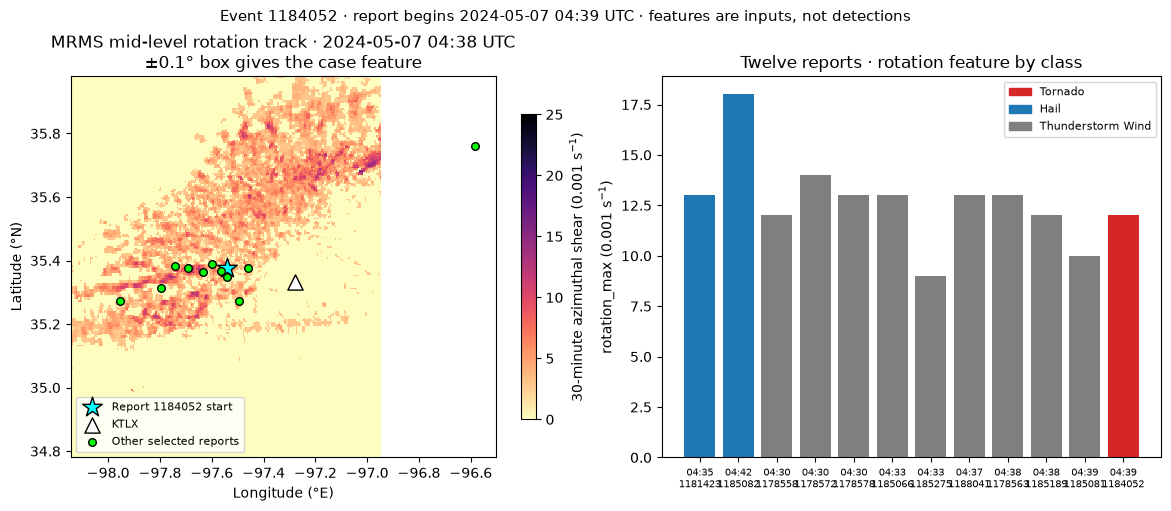

In [7]:
half = 0.6
case_stamp, _ = rotation_max(event_time, lat, lon)
crop = rotation_crops[case_stamp].sel(
    latitude=slice(lat + half, lat - half), longitude=slice(lon + 360 - half, lon + 360 + half)
)
fig, (ax_map, ax_bars) = plt.subplots(1, 2, figsize=(12, 5), layout="constrained")
mesh = ax_map.pcolormesh(
    crop.longitude.values - 360,
    crop.latitude.values,
    crop.values,
    cmap="magma_r",
    shading="auto",
    vmin=0,
    vmax=25,
)
ax_map.scatter(
    lon,
    lat,
    marker="*",
    s=220,
    c="cyan",
    edgecolors="black",
    label="Report 1184052 start",
    zorder=3,
)
ax_map.scatter(
    radar_lon, radar_lat, marker="^", s=120, c="white", edgecolors="black", label="KTLX", zorder=3
)
others = selected.loc[~selected.EVENT_ID.eq(case.EVENT_ID)]
ax_map.scatter(
    others.BEGIN_LON,
    others.BEGIN_LAT,
    marker="o",
    s=30,
    c="lime",
    edgecolors="black",
    label="Other selected reports",
    zorder=3,
)
ax_map.set(
    xlabel="Longitude (°E)",
    ylabel="Latitude (°N)",
    title=(
        f"MRMS mid-level rotation track · {case_stamp:%Y-%m-%d %H:%M} UTC\n"
        "±0.1° box gives the case feature"
    ),
    aspect=1 / np.cos(np.deg2rad(lat)),
)
ax_map.legend(loc="lower left", fontsize=8)
fig.colorbar(mesh, ax=ax_map, label="30-minute azimuthal shear (0.001 s$^{-1}$)", shrink=0.8)
colors = {"Tornado": "#d62728", "Hail": "#1f77b4", "Thunderstorm Wind": "#7f7f7f"}
order = labeled.sort_values(["label", "utc_time"]).reset_index(drop=True)
ax_bars.bar(range(len(order)), order.rotation_max, color=[colors[label] for label in order.label])
ax_bars.set_xticks(
    range(len(order)), [f"{row.utc_time}\n{row.event_id}" for row in order.itertuples()], fontsize=7
)
ax_bars.set(
    ylabel="rotation_max (0.001 s$^{-1}$)", title="Twelve reports · rotation feature by class"
)
ax_bars.legend(
    handles=[plt.Rectangle((0, 0), 1, 1, color=color) for color in colors.values()],
    labels=list(colors),
    fontsize=8,
)
fig.suptitle(
    "Event 1184052 · report begins 2024-05-07 04:39 UTC · features are inputs, not detections",
    fontsize=11,
)
plt.show()
plt.close(fig)
del radar, sweep, crop
gc.collect();

## What this table can and cannot support

- **Times are local standard time.** Every conversion above used the row's
  `CZ_TIMEZONE`. A report from another state or timezone label needs its own
  review before joining to UTC-stamped observations.
- **Several records can describe one storm.** The twelve rows include wind
  reports minutes apart along one supercell's path plus the tornado it produced;
  they are not twelve independent samples, and the rotation feature is nearly the
  same for neighbours because the track product accumulates over 30 minutes.
- **A missing report is not a missing hazard.** Rows without a tornado are
  reports of hail or wind, not evidence that no tornado occurred nearby, and the
  table has no true negatives at all.
- **Twelve rows are a demonstration.** With one tornado, two hail, and nine
  wind rows from a single evening the classes are not separable here, and no
  claim about tornado versus non-tornado rotation values should be read from
  this table.
- **This notebook produces inputs and does not train a model.** A real study
  needs many events across seasons and radars, radar features at every report
  time, environmental fields such as HRRR CAPE and shear, SPC reports as a second
  label source, and independent report review.

## Exercise both restoration paths

A second pull must use verified cached bytes. A separate temporary empty cache
must restore all 80 locked assets without provider re-resolution. This checks the
reproducibility mechanism today; upstream can still remove or revise old files,
so preserve your own source archives. The temporary copy is removed after
verification; the normal cache, manifest, and lock remain available.

In [8]:
again = pull(manifest)
assert again.from_lockfile and all(item.from_cache for item in again.fetched)
assert verify(manifest) == []
with tempfile.TemporaryDirectory(prefix="usdata-tornado-restore-") as directory:
    started = time.perf_counter()
    restored = pull(manifest, root=Path(directory))
    assert restored.from_lockfile and not any(item.from_cache for item in restored.fetched)
    assert verify(manifest, root=Path(directory)) == []
    assert sorted(item.provenance.checksum for item in restored.fetched) == sorted(
        item.provenance.checksum for item in result.fetched
    )
    print("Empty-cache restoration seconds:", round(time.perf_counter() - started, 2))
print(
    f"All {len(result.fetched)} inputs verified; cached and empty-cache locked restoration passed."
)
print("Notebook seconds:", round(time.perf_counter() - notebook_started, 1))

Empty-cache restoration seconds: 11.58
All 80 inputs verified; cached and empty-cache locked restoration passed.
Notebook seconds: 48.1
